<a href="https://colab.research.google.com/github/jamesemcnally/critical-listener/blob/main/source_comparison_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Drive, load slim df and Nomic embeddings.
# Slim df loads only the columns needed for masking and output — avoids RAM crash.

from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import time
from collections import defaultdict

DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks"

df = pd.read_parquet(
    f"{DRIVE_DIR}/merged_dataset_masked.parquet",
    columns=["review_id", "dataset", "artist", "album", "artist_norm", "album_norm"]
)
embeddings = np.load(f"{DRIVE_DIR}/nomic_masked_with_prefix.npy")

print(f"df:         {df.shape}")
print(f"embeddings: {embeddings.shape}")
print(f"\nDataset counts:")
print(df["dataset"].value_counts())


Mounted at /content/drive
df:         (48189, 6)
embeddings: (48189, 768)

Dataset counts:
dataset
pitchfork           22810
resident_advisor    15318
critique_brainz     10061
Name: count, dtype: int64


In [ ]:
# Reusable batch recommender.
# Generates top-k recommendations for every album in the specified source pool
# and saves results to Drive. Same-album and same-artist results are excluded.

def run_recommender(sources, save_name, top_k=10, batch_size=1000):
    print(f"\n{'='*60}")
    print(f"Running: {save_name}")
    print(f"Sources: {sources}")

    # Build pool
    pool_mask = df["dataset"].isin(sources).values
    pool_idx  = np.where(pool_mask)[0].tolist()
    print(f"Pool size: {len(pool_idx):,} albums")

    # Pre-extract arrays for fast per-row access
    _review_ids  = df["review_id"].values
    _artists     = df["artist"].values
    _albums      = df["album"].values
    _datasets    = df["dataset"].values
    _artist_norm = df["artist_norm"].values
    _album_norm  = df["album_norm"].values

    # Lookup: (artist_norm, album_norm) → all row indices (same-album masking)
    album_to_idx = defaultdict(list)
    for i in range(len(df)):
        album_to_idx[(_artist_norm[i], _album_norm[i])].append(i)

    # Lookup: artist_norm → all row indices (same-artist masking)
    artist_to_idx = defaultdict(list)
    for i in range(len(df)):
        artist_to_idx[_artist_norm[i]].append(i)

    # Map global index → position in pool (for fast exclusion)
    global_to_pool_pos = {cidx: j for j, cidx in enumerate(pool_idx)}

    # Pre-extract candidate embeddings once
    pool_emb  = embeddings[pool_idx]
    n_queries = len(pool_idx)

    rows    = []
    t_start = time.time()

    for batch_start in range(0, n_queries, batch_size):
        batch_q_idx = pool_idx[batch_start : batch_start + batch_size]

        batch_emb  = embeddings[batch_q_idx]
        batch_sims = batch_emb @ pool_emb.T

        for i, q in enumerate(batch_q_idx):
            sim_row = batch_sims[i].copy()

            exclude = set(album_to_idx[(_artist_norm[q], _album_norm[q])])
            exclude.update(artist_to_idx[_artist_norm[q]])
            exclude_pos = [global_to_pool_pos[g] for g in exclude
                           if g in global_to_pool_pos]
            if exclude_pos:
                sim_row[exclude_pos] = -np.inf

            top_pos = np.argpartition(sim_row, -top_k)[-top_k:]
            top_pos = top_pos[np.argsort(sim_row[top_pos])[::-1]]

            for rank, pos in enumerate(top_pos, 1):
                rec = pool_idx[pos]
                rows.append({
                    "query_review_id": _review_ids[q],
                    "query_artist":    _artists[q],
                    "query_album":     _albums[q],
                    "query_dataset":   _datasets[q],
                    "rank":            rank,
                    "rec_review_id":   _review_ids[rec],
                    "rec_artist":      _artists[rec],
                    "rec_album":       _albums[rec],
                    "rec_dataset":     _datasets[rec],
                    "rec_score":       round(float(sim_row[pos]), 4),
                })

        done    = min(batch_start + batch_size, n_queries)
        elapsed = time.time() - t_start
        eta     = (n_queries - done) / (done / elapsed) if done > 0 else 0
        if done % 10000 == 0 or done == n_queries:
            print(f"  {done:,}/{n_queries:,}  |  {elapsed:.0f}s elapsed  |  ETA ~{eta:.0f}s")

    df_out = pd.DataFrame(rows)
    save_path = f"{DRIVE_DIR}/{save_name}.parquet"
    df_out.to_parquet(save_path, index=False)

    elapsed = time.time() - t_start
    print(f"\nDone in {elapsed:.1f}s")
    print(f"Saved {len(df_out):,} rows → {save_path}")
    print(f"Unique query albums: {df_out['query_album'].nunique():,}")
    print(f"Unique rec albums:   {df_out['rec_album'].nunique():,}")

    return df_out


In [ ]:
# Generate all three recommendation datasets.
# Dataset 1 runs a Pitchfork-only baseline.
# Datasets 2 and 3 expand the pool to include RA and CritiqueBrainz.
# Filter to query_dataset == "pitchfork" later for apples-to-apples comparison.

df_recs_pf = run_recommender(
    sources   = ["pitchfork"],
    save_name = "recommendations_pitchfork_only"
)

df_recs_pf_ra = run_recommender(
    sources   = ["pitchfork", "resident_advisor"],
    save_name = "recommendations_pitchfork_ra"
)

df_recs_all = run_recommender(
    sources   = ["pitchfork", "resident_advisor", "critique_brainz"],
    save_name = "recommendations_all_sources"
)

print("\nAll datasets saved to Drive.")



Running: recommendations_pitchfork_ra
Sources: ['pitchfork', 'resident_advisor']
Pool size: 38,128 albums
  10,000/38,128  |  4s elapsed  |  ETA ~10s
  20,000/38,128  |  7s elapsed  |  ETA ~6s
  30,000/38,128  |  11s elapsed  |  ETA ~3s
  38,128/38,128  |  14s elapsed  |  ETA ~0s

Done in 14.9s
Saved 381,280 rows → /content/drive/MyDrive/Colab Notebooks/recommendations_pitchfork_ra.parquet
Unique query albums: 35,297
Unique rec albums:   31,937

Running: recommendations_all_sources
Sources: ['pitchfork', 'resident_advisor', 'critique_brainz']
Pool size: 48,189 albums
  10,000/48,189  |  4s elapsed  |  ETA ~15s
  20,000/48,189  |  8s elapsed  |  ETA ~11s
  30,000/48,189  |  13s elapsed  |  ETA ~8s
  40,000/48,189  |  17s elapsed  |  ETA ~3s
  48,189/48,189  |  20s elapsed  |  ETA ~0s

Done in 21.2s
Saved 481,890 rows → /content/drive/MyDrive/Colab Notebooks/recommendations_all_sources.parquet
Unique query albums: 42,339
Unique rec albums:   38,272

All datasets saved to Drive.


## Recommendation Dataset EDA — Three Corpus Configurations

We generated three recommendation datasets using the same Nomic masked embeddings
but expanding the pool of candidate albums at each step:

| Configuration | Query pool | Candidate pool | Rows |
|---|---|---|---|
| Pitchfork only | Pitchfork (22,810) | Pitchfork (22,810) | 228,100 |
| Pitchfork + RA | PF + RA (38,128) | PF + RA (38,128) | 381,280 |
| All sources | All three (48,189) | All three (48,189) | 481,890 |

This EDA has two parts:

**Part 1 — Per-dataset analysis** (run independently on each configuration):
score distribution, hubness, coverage, rating bias, cross-genre rates,
hub album spot-check, and reciprocity.

**Part 2 — Cross-dataset comparison** (apples-to-apples):
filter all three datasets to Pitchfork queries only, then measure what
changed as the candidate pool expanded — which recommendations were added,
which were lost, and whether the expanded pools surface albums that the
Pitchfork-only run missed. These are the hidden gem candidates.


In [ ]:
# Setup: load slim df and all three recommendation datasets from Drive.
# Includes rating and genre columns needed for EDA.

from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks"

df = pd.read_parquet(
    f"{DRIVE_DIR}/merged_dataset_masked.parquet",
    columns=["review_id", "dataset", "artist", "album",
             "artist_norm", "album_norm", "rating", "genre"]
)

df_recs_pf    = pd.read_parquet(f"{DRIVE_DIR}/recommendations_pitchfork_only.parquet")
df_recs_pf_ra = pd.read_parquet(f"{DRIVE_DIR}/recommendations_pitchfork_ra.parquet")
df_recs_all   = pd.read_parquet(f"{DRIVE_DIR}/recommendations_all_sources.parquet")

print(f"df:            {df.shape[0]:,} reviews")
print(f"\nDataset counts:")
print(df["dataset"].value_counts())
print(f"\nRecommendation datasets:")
print(f"  Pitchfork only:  {len(df_recs_pf):,} rows")
print(f"  Pitchfork + RA:  {len(df_recs_pf_ra):,} rows")
print(f"  All sources:     {len(df_recs_all):,} rows")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df:            48,189 reviews

Dataset counts:
dataset
pitchfork           22810
resident_advisor    15318
critique_brainz     10061
Name: count, dtype: int64

Recommendation datasets:
  Pitchfork only:  228,100 rows
  Pitchfork + RA:  381,280 rows
  All sources:     481,890 rows


SCORE DISTRIBUTION

                             PF only    PF + RA        All
─────────────────────────────────────────────────────────
  Mean                        0.7994     0.7967     0.7983
  Median                      0.7992     0.7948     0.7969
  Std                         0.0303     0.0298     0.0304
  Min                         0.6828     0.6828     0.6305
  Max                         0.9695     0.9749     0.9749

  Mean score by rank:
    Rank   Pitchfork on   Pitchfork +     All sources
  ──────────────────────────────────────────────────
       1         0.8197         0.8188         0.8209
       2         0.8093         0.8073         0.8091
       3         0.8039         0.8015         0.8032
       4         0.8004         0.7977         0.7993
       5         0.7977         0.7949         0.7964
       6         0.7956         0.7926         0.7941
       7         0.7938         0.7908         0.7922
       8         0.7924         0.7892         0.7906
      

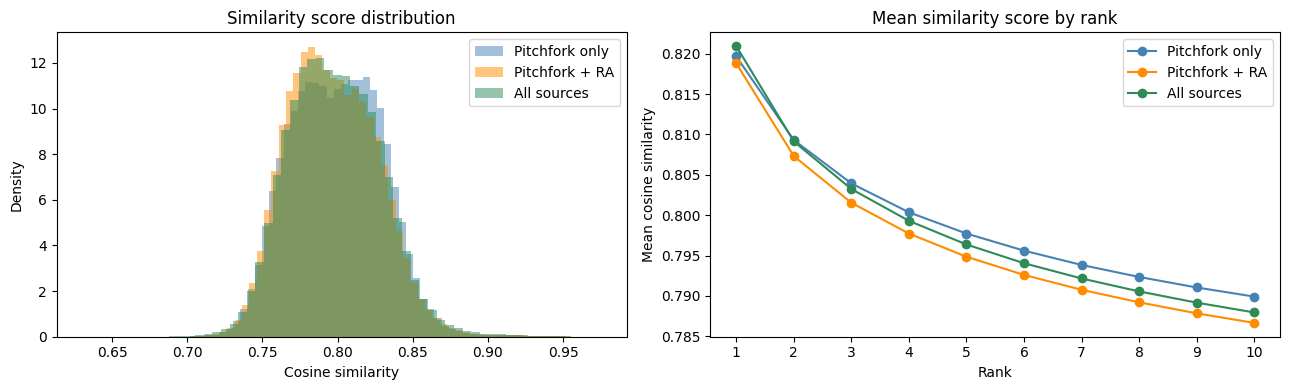

In [ ]:
# EDA Part 1: score distribution — all three datasets overlaid.
# Shows how the similarity score range and rank decay change as the pool expands.

CONFIGS = {
    "Pitchfork only":  df_recs_pf,
    "Pitchfork + RA":  df_recs_pf_ra,
    "All sources":     df_recs_all,
}
COLORS = ["steelblue", "darkorange", "seagreen"]

print("SCORE DISTRIBUTION\n")
print(f"{'':25} {'PF only':>10} {'PF + RA':>10} {'All':>10}")
print("─" * 57)
for label, stat in [
    ("Mean",   lambda d: d["rec_score"].mean()),
    ("Median", lambda d: d["rec_score"].median()),
    ("Std",    lambda d: d["rec_score"].std()),
    ("Min",    lambda d: d["rec_score"].min()),
    ("Max",    lambda d: d["rec_score"].max()),
]:
    vals = [stat(d) for d in CONFIGS.values()]
    print(f"  {label:<23} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")

print(f"\n  Mean score by rank:")
print(f"  {'Rank':>6}", end="")
for label in CONFIGS:
    print(f"  {label[:12]:>13}", end="")
print()
print("  " + "─" * 50)
for rank in range(1, 11):
    print(f"  {rank:>6}", end="")
    for df_r in CONFIGS.values():
        mean = df_r[df_r["rank"] == rank]["rec_score"].mean()
        print(f"  {mean:>13.4f}", end="")
    print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for (label, df_r), color in zip(CONFIGS.items(), COLORS):
    ax1.hist(df_r["rec_score"], bins=60, alpha=0.5,
             label=label, color=color, density=True, edgecolor="none")
ax1.set_title("Similarity score distribution")
ax1.set_xlabel("Cosine similarity")
ax1.set_ylabel("Density")
ax1.legend()

for (label, df_r), color in zip(CONFIGS.items(), COLORS):
    rank_means = df_r.groupby("rank")["rec_score"].mean()
    ax2.plot(rank_means.index, rank_means.values, "o-",
             label=label, color=color)
ax2.set_title("Mean similarity score by rank")
ax2.set_xlabel("Rank")
ax2.set_ylabel("Mean cosine similarity")
ax2.set_xticks(range(1, 11))
ax2.legend()

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/eda_all_1_scores.png", dpi=100)
plt.show()
plt.close()


HUBNESS

Pitchfork only

  Top 15 most-recommended albums:
  Artist                       Album                           Count       %
  ──────────────────────────── ────────────────────────────── ──────  ──────
  Shimmer                      And I Revel                       911   0.40%
  Post Animal                  When I Think of You in a Castl    735   0.32%
  These Are Powers             Terrific Seasons                  687   0.30%
  The Music                    The Music                         572   0.25%
  Sightings                    Amusers and Puzzlers              467   0.20%
  Growing                      All the Way                       393   0.17%
  SW.                          The Album                         373   0.16%
  Beak>                        >>                                345   0.15%
  Hinds                        The Prettiest Curse               336   0.15%
  Original Instrument          Original Instrument               321   0.14%
  Wilderness     

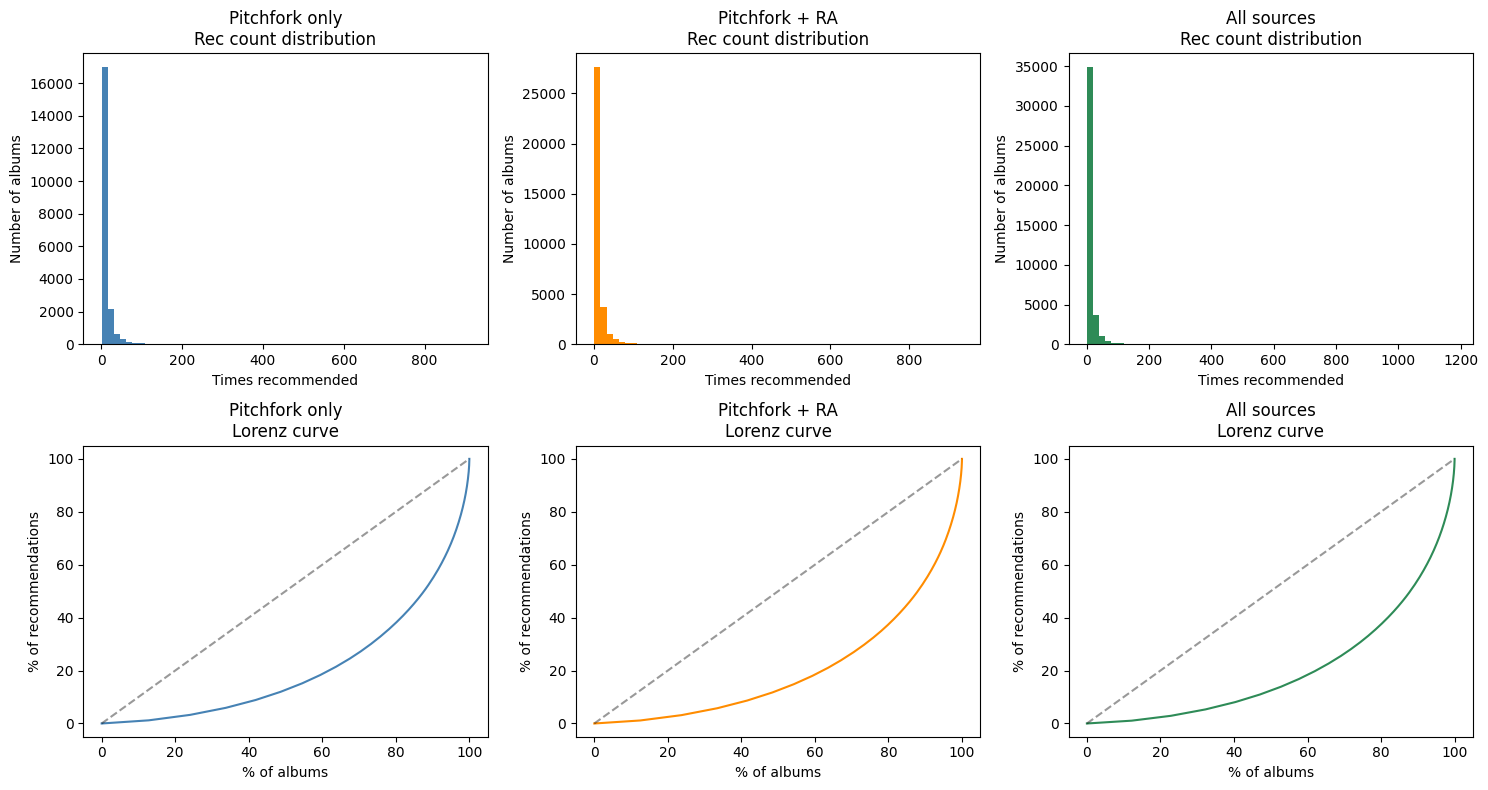

HUB OVERLAP (top 100 hubs per configuration)

  Consistent across all three:            49
  Pitchfork-only hubs (drop when RA added):   38
  New hubs added by RA:                   40
  New hubs added by CritiqueBrainz:       21

  Consistent hubs (appear in all three configurations):
    Acid House Kings — Sing Along With Acid House Kings
    Air — The Virgin Suicides
    Aloha — Here Comes Everyone
    BOAT — Let's Drag Our Feet
    Beak> — >>
    Bellows — Undercurrent
    Booka Shade — More!
    Broadcast — The Noise Made by People
    Cough — Still They Pray
    Do Make Say Think — & Yet & Yet
    Fits — All Belief Is Paradise
    For Stars — ...It Falls Apart
    Growing — All the Way
    Gunplay — Living Legend
    Hem — Eveningland
    Hinds — The Prettiest Curse
    Holy Fuck — Holy Fuck
    Holy Fuck — LP
    Hood — Outside Closer
    Horse Jumper of Love — Horse Jumper of Love

  New hubs introduced by RA (not in Pitchfork-only top 100):
    A Mountain of One — Institute Of

In [ ]:
# EDA Part 2: hubness — which albums dominate recommendations in each dataset,
# and how concentrated is the distribution across all three configurations.
# Also compares hub albums across configurations to identify consistent vs.
# configuration-specific hubs.

print("HUBNESS\n")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hub_sets = {}

for col, (label, df_r) in enumerate(CONFIGS.items()):
    rec_counts = (
        df_r.groupby(["rec_artist", "rec_album"])
        .size()
        .sort_values(ascending=False)
    )
    total_recs = len(df_r)
    hub_sets[label] = set(rec_counts.head(100).index)

    print(f"{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")
    print(f"\n  Top 15 most-recommended albums:")
    print(f"  {'Artist':<28} {'Album':<30} {'Count':>6}  {'%':>6}")
    print(f"  {'─'*28} {'─'*30} {'─'*6}  {'─'*6}")
    for (artist, album), count in rec_counts.head(15).items():
        print(f"  {artist[:28]:<28} {album[:30]:<30} "
              f"{count:>6,}  {count/total_recs*100:>5.2f}%")

    print(f"\n  Concentration:")
    for n in [10, 50, 100, 500]:
        share = rec_counts.head(n).sum() / total_recs * 100
        print(f"    Top {n:>4} albums → {share:.1f}% of all recommendations")
    print()

    # Histogram of rec counts
    axes[0, col].hist(rec_counts.values, bins=60, edgecolor="none",
                      color=COLORS[col])
    axes[0, col].set_title(f"{label}\nRec count distribution")
    axes[0, col].set_xlabel("Times recommended")
    axes[0, col].set_ylabel("Number of albums")

    # Lorenz curve
    sorted_counts = np.sort(rec_counts.values)
    cumulative    = np.cumsum(sorted_counts) / sorted_counts.sum()
    x_pct         = np.linspace(0, 100, len(cumulative))
    axes[1, col].plot(x_pct, cumulative * 100, color=COLORS[col])
    axes[1, col].plot([0, 100], [0, 100], "k--", alpha=0.4)
    axes[1, col].set_title(f"{label}\nLorenz curve")
    axes[1, col].set_xlabel("% of albums")
    axes[1, col].set_ylabel("% of recommendations")

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/eda_all_2_hubness.png", dpi=100)
plt.show()
plt.close()

# Cross-dataset hub overlap (top 100 hubs per configuration)
labels = list(CONFIGS.keys())
pf_only_hubs   = hub_sets[labels[0]]
pf_ra_hubs     = hub_sets[labels[1]]
all_hubs       = hub_sets[labels[2]]

consistent     = pf_only_hubs & pf_ra_hubs & all_hubs
pf_only_unique = pf_only_hubs - pf_ra_hubs - all_hubs
pf_ra_new      = pf_ra_hubs - pf_only_hubs
all_new        = all_hubs - pf_ra_hubs

print(f"HUB OVERLAP (top 100 hubs per configuration)\n")
print(f"  Consistent across all three:          {len(consistent):>4}")
print(f"  Pitchfork-only hubs (drop when RA added): {len(pf_only_unique):>4}")
print(f"  New hubs added by RA:                 {len(pf_ra_new):>4}")
print(f"  New hubs added by CritiqueBrainz:     {len(all_new):>4}")

print(f"\n  Consistent hubs (appear in all three configurations):")
for artist, album in sorted(consistent)[:20]:
    print(f"    {artist} — {album}")

print(f"\n  New hubs introduced by RA (not in Pitchfork-only top 100):")
for artist, album in sorted(pf_ra_new)[:10]:
    print(f"    {artist} — {album}")

print(f"\n  New hubs introduced by CritiqueBrainz (not in PF+RA top 100):")
for artist, album in sorted(all_new)[:10]:
    print(f"    {artist} — {album}")


In [ ]:
# EDA Part 3: coverage — what share of albums in each configuration are ever
# recommended, and how coverage changes as the pool expands.

print("COVERAGE\n")

POOL_SOURCES = {
    "Pitchfork only":  ["pitchfork"],
    "Pitchfork + RA":  ["pitchfork", "resident_advisor"],
    "All sources":     ["pitchfork", "resident_advisor", "critique_brainz"],
}

for label, df_r in CONFIGS.items():
    print(f"{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")

    pool_sources = POOL_SOURCES[label]
    pool         = df[df["dataset"].isin(pool_sources)].copy()

    # Match on (artist_norm, album_norm) — stable across all datasets
    recommended_pairs = set(
        zip(df_r["rec_artist"].str.lower().str.strip(),
            df_r["rec_album"].str.lower().str.strip())
    )
    pool["ever_recommended"] = (
        list(zip(pool["artist_norm"], pool["album_norm"]))
        in recommended_pairs
        if False else  # vectorized below
        [
            (a, b) in recommended_pairs
            for a, b in zip(pool["artist_norm"], pool["album_norm"])
        ]
    )

    never = pool[~pool["ever_recommended"]]
    ever  = pool[ pool["ever_recommended"]]

    print(f"\n  Pool size:           {len(pool):,}")
    print(f"  Ever recommended:    {len(ever):,}  ({len(ever)/len(pool)*100:.1f}%)")
    print(f"  Never recommended:   {len(never):,}  ({len(never)/len(pool)*100:.1f}%)")

    print(f"\n  Never-recommended by source:")
    for src in pool_sources:
        src_pool  = pool[pool["dataset"] == src]
        src_never = never[never["dataset"] == src]
        pct       = len(src_never) / len(src_pool) * 100 if len(src_pool) > 0 else 0
        print(f"    {src:<25} {len(src_never):>5,} / {len(src_pool):>6,}  ({pct:.1f}%)")

    print(f"\n  Rating (0–5 scale):")
    print(f"    Ever recommended  — mean: {ever['rating'].mean():.2f}, "
          f"median: {ever['rating'].median():.2f}")
    print(f"    Never recommended — mean: {never['rating'].mean():.2f}, "
          f"median: {never['rating'].median():.2f}")
    print()

# Cross-configuration coverage gains
print(f"{'='*60}")
print("COVERAGE GAINS ACROSS CONFIGURATIONS")
print(f"{'='*60}\n")

def rec_pairs(df_r):
    return set(zip(df_r["rec_artist"].str.lower().str.strip(),
                   df_r["rec_album"].str.lower().str.strip()))

pf_pairs    = rec_pairs(df_recs_pf)
pf_ra_pairs = rec_pairs(df_recs_pf_ra)
all_pairs   = rec_pairs(df_recs_all)

gained_by_ra = pf_ra_pairs - pf_pairs
gained_by_cb = all_pairs   - pf_ra_pairs

print(f"  Albums recommended in PF only:                {len(pf_pairs):,}")
print(f"  Albums recommended in PF+RA:                  {len(pf_ra_pairs):,}")
print(f"  Albums recommended in all sources:            {len(all_pairs):,}")
print(f"\n  New albums surfaced by adding RA:             {len(gained_by_ra):,}")
print(f"  New albums surfaced by adding CritiqueBrainz: {len(gained_by_cb):,}")

# Source breakdown of newly surfaced albums
def source_of_pairs(pairs):
    mask = [
        (a, b) in pairs
        for a, b in zip(df["artist_norm"], df["album_norm"])
    ]
    return df[mask]["dataset"].value_counts()

print(f"\n  Source of RA-gained albums:")
print(source_of_pairs(gained_by_ra).to_string())
print(f"\n  Source of CB-gained albums:")
print(source_of_pairs(gained_by_cb).to_string())


COVERAGE

Pitchfork only

  Pool size:           22,810
  Ever recommended:    20,503  (89.9%)
  Never recommended:   2,307  (10.1%)

  Never-recommended by source:
    pitchfork                 2,307 / 22,810  (10.1%)

  Rating (0–5 scale):
    Ever recommended  — mean: 3.54, median: 3.65
    Never recommended — mean: 3.43, median: 3.55

Pitchfork + RA

  Pool size:           38,128
  Ever recommended:    34,531  (90.6%)
  Never recommended:   3,597  (9.4%)

  Never-recommended by source:
    pitchfork                 2,130 / 22,810  (9.3%)
    resident_advisor          1,467 / 15,318  (9.6%)

  Rating (0–5 scale):
    Ever recommended  — mean: 3.60, median: 3.65
    Never recommended — mean: 3.50, median: 3.50

All sources

  Pool size:           48,189
  Ever recommended:    43,734  (90.8%)
  Never recommended:   4,455  (9.2%)

  Never-recommended by source:
    pitchfork                 2,038 / 22,810  (8.9%)
    resident_advisor          1,503 / 15,318  (9.8%)
    critique_brainz 

RATING BIAS

                             PF only    PF + RA        All
─────────────────────────────────────────────────────────
  Correlation (r):             0.0235
  Correlation (r):             0.0108
  Correlation (r):             0.0167

  Mean rec rating by rank:
    Rank   Pitchfork on   Pitchfork +     All sources
  ──────────────────────────────────────────────────
       1          3.575          3.633          3.625
       2          3.585          3.642          3.637
       3          3.591          3.644          3.639
       4          3.591          3.639          3.636
       5          3.588          3.639          3.635
       6          3.588          3.640          3.633
       7          3.584          3.638          3.635
       8          3.592          3.638          3.638
       9          3.592          3.637          3.628
      10          3.590          3.637          3.637


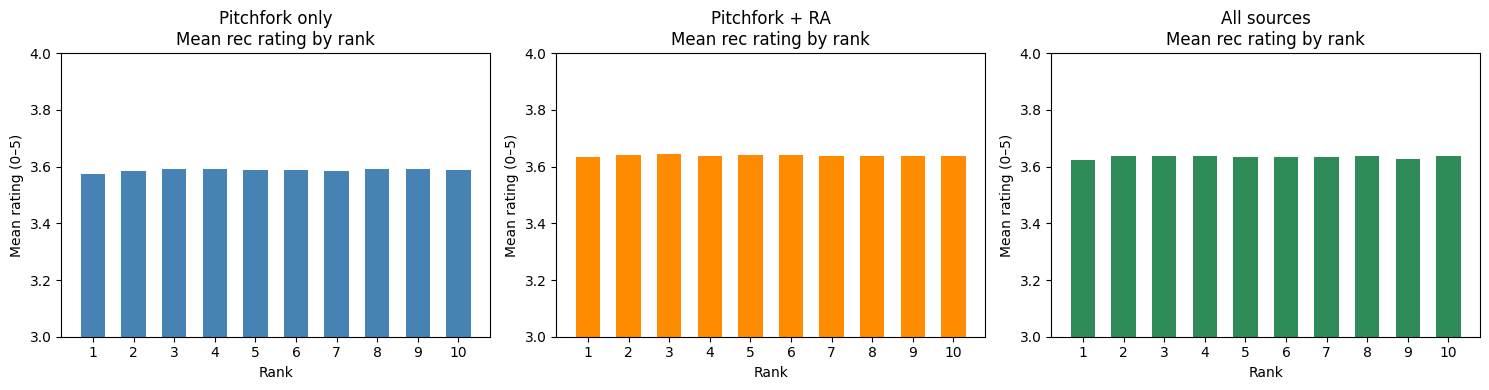

In [ ]:
# EDA Part 4: rating bias — does higher similarity correlate with
# better-reviewed recommendations, and does this change across configurations?

print("RATING BIAS\n")

meta = (
    df.drop_duplicates(subset=["artist_norm", "album_norm"])
    [["artist_norm", "album_norm", "rating"]]
    .copy()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

print(f"{'':25} {'PF only':>10} {'PF + RA':>10} {'All':>10}")
print("─" * 57)

rank_rating_all = {}

for col, (label, df_r) in enumerate(CONFIGS.items()):
    merged = df_r.merge(
        meta.rename(columns={
            "artist_norm": "rec_artist_norm",
            "album_norm":  "rec_album_norm",
            "rating":      "rec_rating"
        }),
        left_on  = [df_r["rec_artist"].str.lower().str.strip(),
                    df_r["rec_album"].str.lower().str.strip()],
        right_on = ["rec_artist_norm", "rec_album_norm"],
        how      = "left"
    ).dropna(subset=["rec_rating"])

    corr         = merged["rec_score"].corr(merged["rec_rating"])
    rank_ratings = merged.groupby("rank")["rec_rating"].mean()
    rank_rating_all[label] = rank_ratings

    axes[col].bar(rank_ratings.index, rank_ratings.values, width=0.6,
                  color=COLORS[col])
    axes[col].set_title(f"{label}\nMean rec rating by rank")
    axes[col].set_xlabel("Rank")
    axes[col].set_ylabel("Mean rating (0–5)")
    axes[col].set_xticks(range(1, 11))
    axes[col].set_ylim(3.0, 4.0)

    print(f"  Correlation (r):         {corr:>10.4f}")

print(f"\n  Mean rec rating by rank:")
print(f"  {'Rank':>6}", end="")
for label in CONFIGS:
    print(f"  {label[:12]:>13}", end="")
print()
print("  " + "─" * 50)
for rank in range(1, 11):
    print(f"  {rank:>6}", end="")
    for label in rank_rating_all:
        print(f"  {rank_rating_all[label].get(rank, float('nan')):>13.3f}", end="")
    print()

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/eda_all_4_rating_bias.png", dpi=100)
plt.show()
plt.close()


Pitchfork only — within-genre ratios (diagonal)
  Rock            1.53x
  Electronic      2.32x
  Rap             7.58x
  Experimental    2.58x
  Pop/R&B         3.30x
  Metal           11.85x
  Folk/Country    5.14x
  Jazz            20.60x

Pitchfork + RA — within-genre ratios (diagonal)
  Rock            1.57x
  Electronic      2.25x
  Rap             7.88x
  Experimental    2.17x
  Pop/R&B         3.44x
  Metal           12.34x
  Folk/Country    5.34x
  Jazz            20.16x

All sources — within-genre ratios (diagonal)
  Rock            1.57x
  Electronic      2.29x
  Rap             7.92x
  Experimental    2.18x
  Pop/R&B         3.44x
  Metal           12.66x
  Folk/Country    5.17x
  Jazz            17.98x



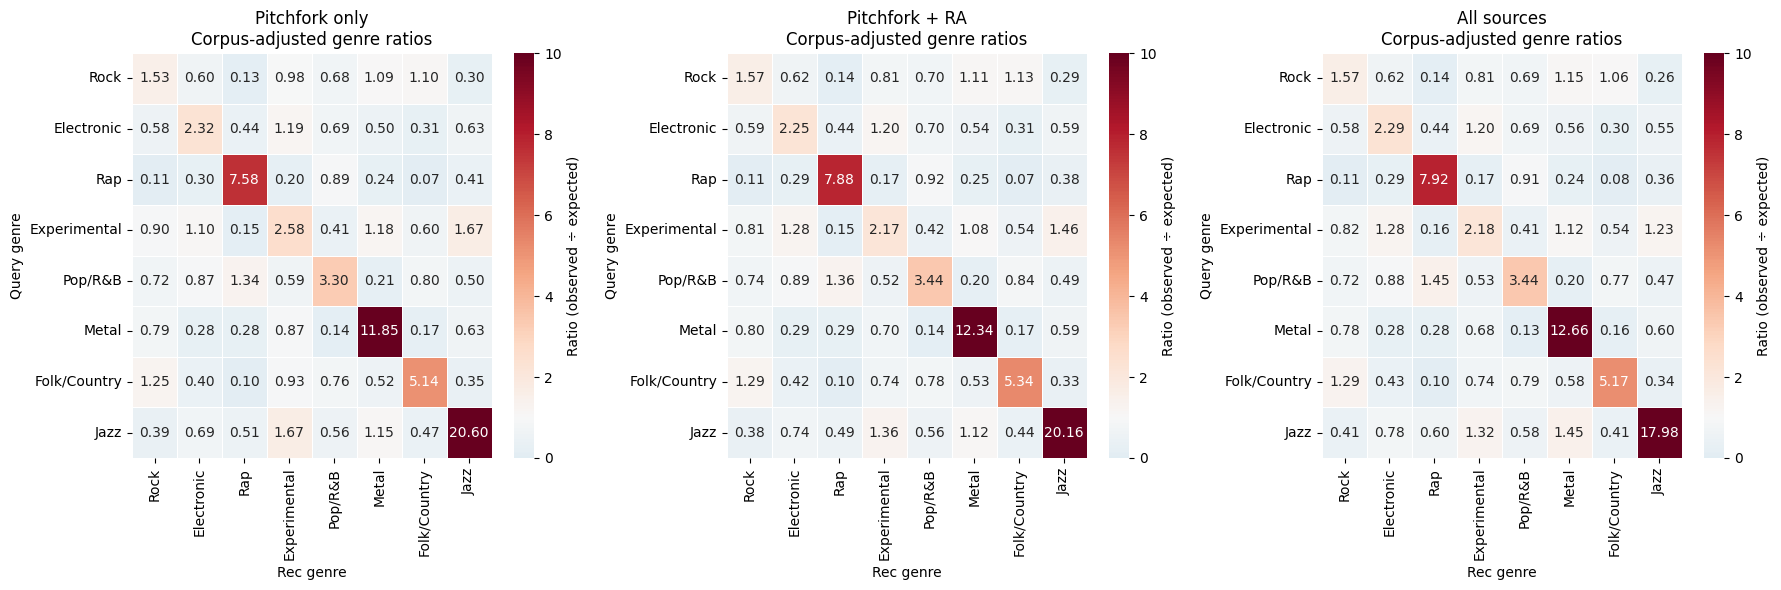

In [ ]:
# EDA Part 5: cross-genre recommendation rates — adjusted for corpus size.
# Runs on all three configurations and shows how genre bridging changes
# as the candidate pool expands.

MAIN_GENRES = ["Rock", "Electronic", "Rap", "Experimental",
               "Pop/R&B", "Metal", "Folk/Country", "Jazz"]

def primary_genre(g):
    if pd.isna(g):
        return None
    return g.split(",")[0].strip()

# Genre lookup: (artist_norm, album_norm) → primary genre
genre_lookup = (
    df.drop_duplicates(subset=["artist_norm", "album_norm"])
    .assign(primary_genre=lambda x: x["genre"].apply(primary_genre))
    [["artist_norm", "album_norm", "primary_genre"]]
)
genre_dict = {
    (row.artist_norm, row.album_norm): row.primary_genre
    for row in genre_lookup.itertuples()
}

# Corpus base rates per configuration
def get_base_rates(pool_sources):
    pool_genres = [
        primary_genre(g)
        for g in df[df["dataset"].isin(pool_sources)]["genre"]
    ]
    pool_genres = [g for g in pool_genres if g in MAIN_GENRES]
    total = len(pool_genres)
    return {g: pool_genres.count(g) / total * 100 for g in MAIN_GENRES}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for col, (label, df_r) in enumerate(CONFIGS.items()):
    pool_sources = POOL_SOURCES[label]
    base_rates   = get_base_rates(pool_sources)

    df_r["query_genre_primary"] = [
        genre_dict.get((a, b))
        for a, b in zip(
            df_r["query_artist"].str.lower().str.strip(),
            df_r["query_album"].str.lower().str.strip()
        )
    ]
    df_r["rec_genre_primary"] = [
        genre_dict.get((a, b))
        for a, b in zip(
            df_r["rec_artist"].str.lower().str.strip(),
            df_r["rec_album"].str.lower().str.strip()
        )
    ]

    df_cross = df_r[
        df_r["query_genre_primary"].isin(MAIN_GENRES) &
        df_r["rec_genre_primary"].isin(MAIN_GENRES)
    ]

    crosstab = pd.crosstab(
        df_cross["query_genre_primary"],
        df_cross["rec_genre_primary"],
        normalize="index"
    ) * 100
    crosstab = crosstab.reindex(index=MAIN_GENRES, columns=MAIN_GENRES, fill_value=0)

    ratio_table = crosstab.copy()
    for g in MAIN_GENRES:
        if g in ratio_table.columns and base_rates.get(g, 0) > 0:
            ratio_table[g] = ratio_table[g] / base_rates[g]

    print(f"{'='*60}")
    print(f"{label} — within-genre ratios (diagonal)")
    print(f"{'='*60}")
    for g in MAIN_GENRES:
        if g in ratio_table.index:
            print(f"  {g:<15} {ratio_table.loc[g, g]:.2f}x")
    print()

    sns.heatmap(
        ratio_table, annot=True, fmt=".2f", cmap="RdBu_r",
        center=1.0, linewidths=0.5, ax=axes[col],
        cbar_kws={"label": "Ratio (observed ÷ expected)"},
        vmin=0, vmax=10
    )
    axes[col].set_title(f"{label}\nCorpus-adjusted genre ratios")
    axes[col].set_xlabel("Rec genre")
    axes[col].set_ylabel("Query genre")

    df_r.drop(columns=["query_genre_primary", "rec_genre_primary"], inplace=True)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/eda_all_5_cross_genre.png", dpi=100)
plt.show()
plt.close()


In [ ]:
# EDA Part 6: hub album spot-check — reads review text for the top 5 hubs
# in each configuration to determine whether they're hubs because of rich,
# distinctive writing or generic critical language.

df_text = pd.read_parquet(
    f"{DRIVE_DIR}/merged_dataset_masked.parquet",
    columns=["artist_norm", "album_norm", "dataset", "cleaned_text"]
)

text_dict = {
    (row.artist_norm, row.album_norm, row.dataset): row.cleaned_text
    for row in df_text.itertuples()
}
del df_text

for label, df_r in CONFIGS.items():
    print(f"\n{'='*70}")
    print(f"TOP 5 HUBS — {label.upper()}")
    print(f"{'='*70}")

    hub_df = (
        df_r.groupby(["rec_artist", "rec_album"])
        .size()
        .reset_index(name="rec_count")
        .sort_values("rec_count", ascending=False)
        .head(5)
    )

    for _, row in hub_df.iterrows():
        a_norm = row["rec_artist"].lower().strip()
        b_norm = row["rec_album"].lower().strip()

        # Try each source in pool order
        text = None
        for src in POOL_SOURCES[label]:
            text = text_dict.get((a_norm, b_norm, src))
            if text:
                break

        print(f"\n{'─'*70}")
        print(f"{row['rec_artist']} — {row['rec_album']}")
        print(f"Recommended {row['rec_count']:,} times")
        print(f"{'─'*70}")
        print(text[:500] if text else "[review text not found]")
        print("...")



TOP 5 HUBS — PITCHFORK ONLY

──────────────────────────────────────────────────────────────────────
Shimmer — And I Revel
Recommended 911 times
──────────────────────────────────────────────────────────────────────
Each of the four members of New York band Shimmer have spent the better part of the past decade exploring the frayed fringes of rock music. Anina Ivry-Block and Nina Ryser make chattery, absurdist miniatures as Palberta. Paco Cathcart's solo endeavor the Cradle is an idiosyncratic exploration of "analog natural jank." Simon Hanes, once a member of the psycho-surrealists Guerilla Toss, makes intricately arranged instrumentals as Tredici Bacci. As exploratory and otherworldly as their music is sep
...

──────────────────────────────────────────────────────────────────────
Post Animal — When I Think of You in a Castle
Recommended 735 times
──────────────────────────────────────────────────────────────────────
Psychedelia comes in many guises, and Post Animal wear just about al

RECIPROCITY



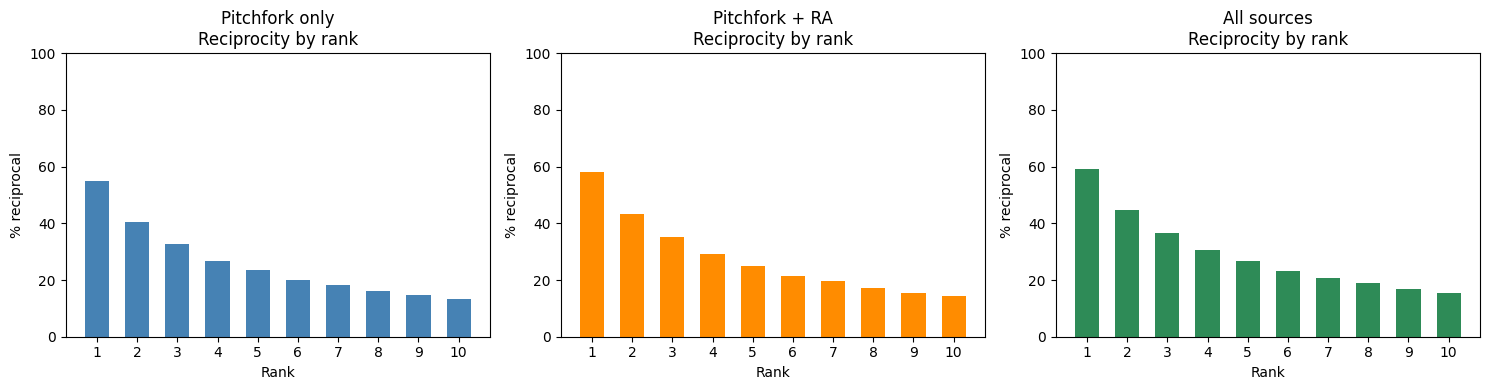

                             PF only    PF + RA        All
─────────────────────────────────────────────────────────
  Overall rate                 26.1%      27.9%      29.3%

  Reciprocity by rank:
    Rank   Pitchfork on   Pitchfork +     All sources
  ──────────────────────────────────────────────────
       1          55.1%          58.2%          59.1%
       2          40.5%          43.3%          44.5%
       3          32.7%          35.0%          36.6%
       4          26.8%          29.3%          30.6%
       5          23.4%          25.1%          26.8%
       6          20.2%          21.5%          23.2%
       7          18.3%          19.6%          20.7%
       8          16.0%          17.3%          18.9%
       9          14.7%          15.6%          17.0%
      10          13.4%          14.3%          15.3%


In [ ]:
# EDA Part 7: reciprocity — if album A recommends album B, does B recommend A?
# Runs across all three configurations and compares how reciprocity changes
# as the pool expands.

print("RECIPROCITY\n")

fig, axes        = plt.subplots(1, 3, figsize=(15, 4))
rank_recip_all   = {}
overall_rates    = {}

for col, (label, df_r) in enumerate(CONFIGS.items()):
    pair_set = set(zip(
        df_r["query_artist"].str.lower().str.strip(),
        df_r["query_album"].str.lower().str.strip(),
        df_r["rec_artist"].str.lower().str.strip(),
        df_r["rec_album"].str.lower().str.strip()
    ))

    df_r["is_reciprocal"] = [
        (ra.lower().strip(), rb.lower().strip(),
         qa.lower().strip(), qb.lower().strip()) in pair_set
        for qa, qb, ra, rb in zip(
            df_r["query_artist"], df_r["query_album"],
            df_r["rec_artist"],   df_r["rec_album"]
        )
    ]

    overall_rates[label]   = df_r["is_reciprocal"].mean() * 100
    rank_recip             = df_r.groupby("rank")["is_reciprocal"].mean() * 100
    rank_recip_all[label]  = rank_recip

    axes[col].bar(rank_recip.index, rank_recip.values,
                  width=0.6, color=COLORS[col])
    axes[col].set_title(f"{label}\nReciprocity by rank")
    axes[col].set_xlabel("Rank")
    axes[col].set_ylabel("% reciprocal")
    axes[col].set_xticks(range(1, 11))
    axes[col].set_ylim(0, 100)

    df_r.drop(columns=["is_reciprocal"], inplace=True)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/eda_all_7_reciprocity.png", dpi=100)
plt.show()
plt.close()

# Summary table
print(f"{'':25} {'PF only':>10} {'PF + RA':>10} {'All':>10}")
print("─" * 57)
print(f"  {'Overall rate':<23}", end="")
for label in CONFIGS:
    print(f"  {overall_rates[label]:>8.1f}%", end="")
print()

print(f"\n  Reciprocity by rank:")
print(f"  {'Rank':>6}", end="")
for label in CONFIGS:
    print(f"  {label[:12]:>13}", end="")
print()
print("  " + "─" * 50)
for rank in range(1, 11):
    print(f"  {rank:>6}", end="")
    for label in rank_recip_all:
        print(f"  {rank_recip_all[label].get(rank, float('nan')):>12.1f}%", end="")
    print()


CROSS-DATASET COMPARISON (Pitchfork queries only)

  Pitchfork queries per slice:
    PF only:  22,032
    PF + RA:  22,149
    All:      22,220

Building per-query rec sets (this may take ~30s)...
Done.

  Queries present in all three slices: 22,810

  Mean shared recs in top-10 (out of 10):
    PF only vs PF+RA:   8.96
    PF only vs All:     7.73
    PF+RA vs All:       8.83

  Most frequently surfaced NEW albums when RA is added:
  Artist                         Album                                Queries
  ────────────────────────────── ─────────────────────────────────── ────────
  woo                            awaawaa                                  673
  snd                            atavism                                  310
  and                            cosmic microwave background              174
  a mountain of one              institute of joy                         165
  and                            social decay                             134
  instra:mental 

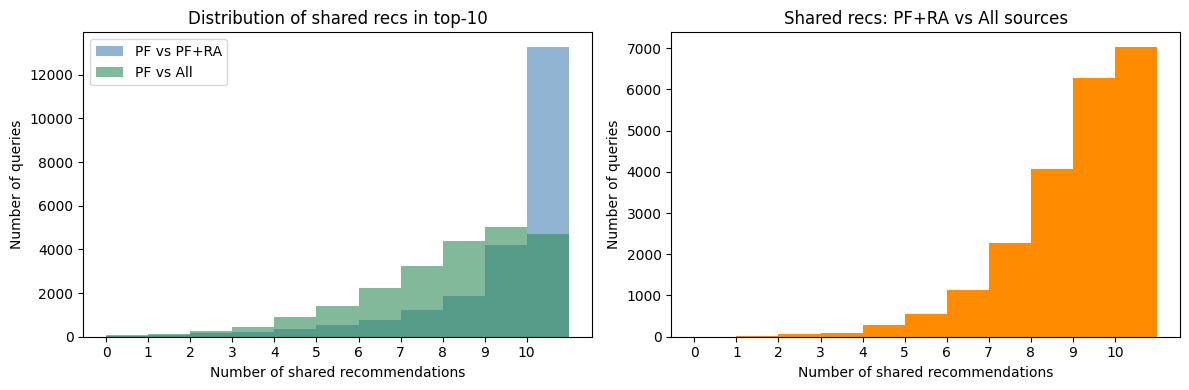

In [ ]:
# Part 2, Cell 1: Cross-dataset comparison — apples-to-apples.
# Filters all three datasets to Pitchfork queries only, then measures
# how much the top-10 recommendations change as the pool expands.

print("CROSS-DATASET COMPARISON (Pitchfork queries only)\n")

# Build Pitchfork query key set from PF-only dataset
pf_query_keys = set(zip(
    df_recs_pf["query_artist"].str.lower().str.strip(),
    df_recs_pf["query_album"].str.lower().str.strip()
))

def filter_to_pf_queries(df_r):
    mask = [
        (a.lower().strip(), b.lower().strip()) in pf_query_keys
        for a, b in zip(df_r["query_artist"], df_r["query_album"])
    ]
    return df_r[mask].copy()

pf_slice    = df_recs_pf.copy()
pf_ra_slice = filter_to_pf_queries(df_recs_pf_ra)
all_slice   = filter_to_pf_queries(df_recs_all)

print(f"  Pitchfork queries per slice:")
print(f"    PF only:  {pf_slice['query_album'].nunique():,}")
print(f"    PF + RA:  {pf_ra_slice['query_album'].nunique():,}")
print(f"    All:      {all_slice['query_album'].nunique():,}\n")

# Build per-query rec sets: (query_key) → set of (rec_artist, rec_album)
def rec_set_by_query(df_r):
    out = {}
    for (qa, qb), grp in df_r.groupby([
        df_r["query_artist"].str.lower().str.strip(),
        df_r["query_album"].str.lower().str.strip()
    ]):
        out[(qa, qb)] = set(zip(
            grp["rec_artist"].str.lower().str.strip(),
            grp["rec_album"].str.lower().str.strip()
        ))
    return out

print("Building per-query rec sets (this may take ~30s)...")
sets_pf    = rec_set_by_query(pf_slice)
sets_pf_ra = rec_set_by_query(pf_ra_slice)
sets_all   = rec_set_by_query(all_slice)
print("Done.\n")

# Overlap: average number of shared recs between PF-only and expanded pools
common_queries = set(sets_pf) & set(sets_pf_ra) & set(sets_all)
print(f"  Queries present in all three slices: {len(common_queries):,}\n")

overlap_pf_vs_pfra = []
overlap_pf_vs_all  = []
overlap_pfra_vs_all = []

for q in common_queries:
    s_pf    = sets_pf[q]
    s_pf_ra = sets_pf_ra[q]
    s_all   = sets_all[q]
    overlap_pf_vs_pfra.append(len(s_pf & s_pf_ra))
    overlap_pf_vs_all.append(len(s_pf & s_all))
    overlap_pfra_vs_all.append(len(s_pf_ra & s_all))

print(f"  Mean shared recs in top-10 (out of 10):")
print(f"    PF only vs PF+RA:   {sum(overlap_pf_vs_pfra)/len(overlap_pf_vs_pfra):.2f}")
print(f"    PF only vs All:     {sum(overlap_pf_vs_all)/len(overlap_pf_vs_all):.2f}")
print(f"    PF+RA vs All:       {sum(overlap_pfra_vs_all)/len(overlap_pfra_vs_all):.2f}")

# New recs surfaced in expanded pools (not in PF-only top-10 for same query)
new_in_pf_ra = []
new_in_all   = []
for q in common_queries:
    new_in_pf_ra.extend(sets_pf_ra[q] - sets_pf[q])
    new_in_all.extend(sets_all[q] - sets_pf_ra[q])

new_pf_ra_counts = pd.Series(new_in_pf_ra).value_counts()
new_all_counts   = pd.Series(new_in_all).value_counts()

print(f"\n  Most frequently surfaced NEW albums when RA is added:")
print(f"  {'Artist':<30} {'Album':<35} {'Queries':>8}")
print(f"  {'─'*30} {'─'*35} {'─'*8}")
for (artist, album), count in new_pf_ra_counts.head(15).items():
    print(f"  {artist[:30]:<30} {album[:35]:<35} {count:>8,}")

print(f"\n  Most frequently surfaced NEW albums when CritiqueBrainz is added:")
print(f"  {'Artist':<30} {'Album':<35} {'Queries':>8}")
print(f"  {'─'*30} {'─'*35} {'─'*8}")
for (artist, album), count in new_all_counts.head(15).items():
    print(f"  {artist[:30]:<30} {album[:35]:<35} {count:>8,}")

# Distribution of overlap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(overlap_pf_vs_pfra, bins=range(0, 12), alpha=0.6,
         label="PF vs PF+RA", color=COLORS[0])
ax1.hist(overlap_pf_vs_all, bins=range(0, 12), alpha=0.6,
         label="PF vs All", color=COLORS[2])
ax1.set_title("Distribution of shared recs in top-10")
ax1.set_xlabel("Number of shared recommendations")
ax1.set_ylabel("Number of queries")
ax1.set_xticks(range(0, 11))
ax1.legend()

ax2.hist(overlap_pfra_vs_all, bins=range(0, 12),
         color=COLORS[1], edgecolor="none")
ax2.set_title("Shared recs: PF+RA vs All sources")
ax2.set_xlabel("Number of shared recommendations")
ax2.set_ylabel("Number of queries")
ax2.set_xticks(range(0, 11))

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/eda_part2_1_overlap.png", dpi=100)
plt.show()
plt.close()


In [ ]:
# Part 2, Cell 2: hidden gem candidates.
# Albums from RA or CritiqueBrainz that surface as strong recommendations
# (rank ≤ 5) for Pitchfork queries in the expanded pools — albums the
# Pitchfork-only system couldn't find because they weren't in its pool.

print("HIDDEN GEM CANDIDATES\n")

# RA albums surfacing in top-5 for Pitchfork queries (PF+RA dataset)
ra_gems = (
    pf_ra_slice[
        (pf_ra_slice["rec_dataset"] == "resident_advisor") &
        (pf_ra_slice["rank"] <= 5)
    ]
    .groupby(["rec_artist", "rec_album"])
    .agg(
        times_recommended = ("rec_score", "count"),
        mean_score        = ("rec_score", "mean"),
        best_score        = ("rec_score", "max"),
        best_rank         = ("rank", "min")
    )
    .sort_values("times_recommended", ascending=False)
    .reset_index()
)

# CB albums surfacing in top-5 for Pitchfork queries (All sources dataset)
cb_gems = (
    all_slice[
        (all_slice["rec_dataset"] == "critique_brainz") &
        (all_slice["rank"] <= 5)
    ]
    .groupby(["rec_artist", "rec_album"])
    .agg(
        times_recommended = ("rec_score", "count"),
        mean_score        = ("rec_score", "mean"),
        best_score        = ("rec_score", "max"),
        best_rank         = ("rank", "min")
    )
    .sort_values("times_recommended", ascending=False)
    .reset_index()
)

print(f"  RA albums surfacing in top-5 for Pitchfork queries: {len(ra_gems):,}")
print(f"  CB albums surfacing in top-5 for Pitchfork queries: {len(cb_gems):,}\n")

print(f"  Top 20 RA hidden gem candidates (by times recommended):")
print(f"  {'Artist':<28} {'Album':<32} {'Times':>6} {'Mean score':>11} {'Best rank':>10}")
print(f"  {'─'*28} {'─'*32} {'─'*6} {'─'*11} {'─'*10}")
for _, row in ra_gems.head(20).iterrows():
    print(f"  {row['rec_artist'][:28]:<28} {row['rec_album'][:32]:<32} "
          f"{row['times_recommended']:>6,} {row['mean_score']:>11.4f} "
          f"{row['best_rank']:>10}")

print(f"\n  Top 20 CB hidden gem candidates (by times recommended):")
print(f"  {'Artist':<28} {'Album':<32} {'Times':>6} {'Mean score':>11} {'Best rank':>10}")
print(f"  {'─'*28} {'─'*32} {'─'*6} {'─'*11} {'─'*10}")
for _, row in cb_gems.head(20).iterrows():
    print(f"  {row['rec_artist'][:28]:<28} {row['rec_album'][:32]:<32} "
          f"{row['times_recommended']:>6,} {row['mean_score']:>11.4f} "
          f"{row['best_rank']:>10}")

# Save both tables
ra_gems.to_parquet(f"{DRIVE_DIR}/hidden_gems_ra.parquet", index=False)
cb_gems.to_parquet(f"{DRIVE_DIR}/hidden_gems_cb.parquet", index=False)
print(f"\nSaved hidden gem tables to Drive.")


HIDDEN GEM CANDIDATES

  RA albums surfacing in top-5 for Pitchfork queries: 4,648
  CB albums surfacing in top-5 for Pitchfork queries: 5,213

  Top 20 RA hidden gem candidates (by times recommended):
  Artist                       Album                             Times  Mean score  Best rank
  ──────────────────────────── ──────────────────────────────── ────── ─────────── ──────────
  Woo                          Awaawaa                             372      0.8299          1
  snd                          Atavism                             157      0.8287          1
  AnD                          Cosmic Microwave Background          94      0.8328          1
  AnD                          Social Decay                         75      0.8292          1
  A Mountain of One            Institute Of Joy                     73      0.8291          1
  Applescal                    A Mishmash Of Changing Moods         58      0.8186          1
  Studio                       Yearbook 2     

## Prepare for metadata join with MusicBrainz database

In [ ]:
# Collapse merged_dataset_masked.parquet to one row per unique album.
# Drops all review text. Aggregates per-source rows: sources as list,
# mean rating, Pitchfork genre tag, date range of reviews.
import pandas as pd

DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks"

LOAD_COLS = [
    "dataset", "artist", "album", "artist_norm", "album_norm",
    "genre", "rating", "published_on", "ra_recommends", "source"
]

df = pd.read_parquet(f"{DRIVE_DIR}/merged_dataset_masked.parquet", columns=LOAD_COLS)
print(f"Loaded: {len(df):,} reviews")
print(f"source == dataset: {(df['source'] == df['dataset']).mean():.1%} of rows")

def agg_album(g):
    pf  = g[g["dataset"] == "pitchfork"]
    ref = pf.iloc[0] if len(pf) > 0 else g.iloc[0]
    return pd.Series({
        "artist":           ref["artist"],
        "album":            ref["album"],
        "artist_norm":      ref["artist_norm"],
        "album_norm":       ref["album_norm"],
        "genre_pitchfork":  ref["genre"],
        "rating_mean":      round(g["rating"].mean(), 4),
        "rating_pf":        round(pf["rating"].mean(), 4) if len(pf) > 0 else None,
        "sources":          sorted(g["dataset"].unique().tolist()),
        "n_sources":        g["dataset"].nunique(),
        "published_on_min": g["published_on"].min(),
        "published_on_max": g["published_on"].max(),
        "ra_recommends":    bool(g["ra_recommends"].any()),
    })

df_albums = (
    df.groupby(["artist_norm", "album_norm"], sort=False)
      .apply(agg_album)
      .reset_index(drop=True)
)

print(f"Unique albums:       {len(df_albums):,}")
print(f"Multi-source albums: {(df_albums['n_sources'] > 1).sum():,}")

df_albums.to_parquet(f"{DRIVE_DIR}/album_catalog.parquet", index=False)
print("Saved: album_catalog.parquet")


Loaded: 48,189 reviews
source == dataset: 0.0% of rows
Unique albums:       44,716
Multi-source albums: 3,293
Saved: album_catalog.parquet


/tmp/ipykernel_3930/3008519154.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_album)
